### Motion planner

In [ ]:
from example_robot_data import load
from pinocchio.visualize import MeshcatVisualizer
import numpy as np
import time
import pinocchio as pin
import meshcat
import rockit
import casadi as ca
from pinocchio import casadi as cpin
import matplotlib.pyplot as plt

In [ ]:
# -- Define boundaries and init conditions --

x_max = 20
y_max = 15

grid = np.zeros((y_max, x_max))

x_start, y_start = 5, 2
x_goal, y_goal = 17, 13

# -- Define obstacles coordinates --
obstacles = [
    [(9, 5.5), (4, 4), (8, 1), (7, 3.5)],
    [(4, 12), (2, 8), (8, 11), (9, 7), (6, 9)],
    [(13, 12), (11, 9), (16,8)]
]

plt.imshow(grid, cmap='Greys', origin='lower')
plt.plot(x_start, y_start, color='blue', marker='o', label='Start')
plt.plot(x_goal, y_goal, color='green', marker='x', label='Goal')
plt.plot(9, 5.5, color='red', marker='s', label='Obstacle 1')
plt.plot(4, 4, color='red', marker='s', label='Obstacle 1')
plt.plot(8, 1, color='red', marker='s', label='Obstacle 1')
plt.plot(7, 3.5, color='red', marker='s', label='Obstacle 1')
plt.show()




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.path import Path

# -- Define boundaries and init conditions --
x_max = 20
y_max = 15
res = 0.25

ny = int(y_max/res)
nx = int(x_max/res)
grid = np.zeros((ny, nx))

x_start, y_start = 5/res, 2/res
x_goal, y_goal = 17/res, 13/res

# -- Define obstacles corner coordinates --
obstacles = [
    [(7/res, 3/res), (8/res, 1/res), (4/res, 4/res), (8/res, 5.5/res)],
    [(2/res, 8/res), (4/res, 12/res), (8/res, 11.5/res), (9/res, 7/res), (6/res, 10/res)],
    [(13/res, 12/res), (11/res, 9/res), (16/res, 8/res)]
]

# -- Mark obstacle cells in grid --
for obs in obstacles:
    path = Path(obs)

    for y in range(ny):
        for x in range(nx):
            # Use cell center
            point = (x + 0.5, y + 0.5)

            if path.contains_point(point):
                grid[y, x] = 1

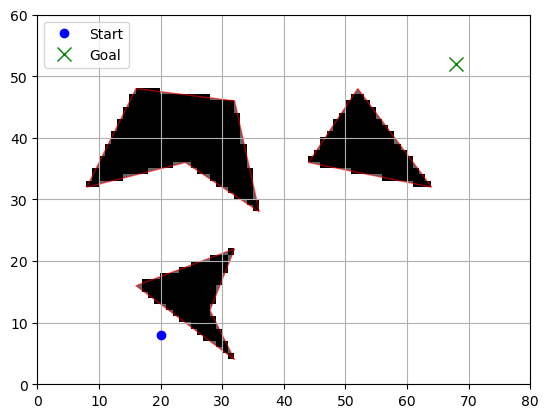

In [88]:
fig, ax = plt.subplots()

ax.imshow(
    grid,
    cmap="Greys",
    origin="lower",
    extent=[0, nx, 0, ny]
)

# Plot filled polygon obstacles
for obs in obstacles:
    poly = Polygon(obs, closed=True, facecolor="black", edgecolor="red", alpha=0.6)
    ax.add_patch(poly)

# Plot start and goal
ax.plot(x_start, y_start, "bo", label="Start")
ax.plot(x_goal, y_goal, "gx", markersize=10, label="Goal")

ax.set_xlim(0, nx)
ax.set_ylim(0, ny)
ax.set_aspect("equal")
ax.grid(True)
ax.legend()

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import heapq

def astar(grid, start, goal):
    # 8-connectivity (diagonal movement allowed)
    neighbors = [(0,1), (0,-1), (1,0), (-1,0), (1,1), (1,-1), (-1,1), (-1,-1)]
    
    close_set = set()
    came_from = {}
    gscore = {start: 0}
    fscore = {start: heuristic(start, goal)}
    oheap = []
    
    heapq.heappush(oheap, (fscore[start], start))
    
    while oheap:
        current = heapq.heappop(oheap)[1]
        
        if current == goal:
            data = []
            while current in came_from:
                data.append(current)
                current = came_from[current]
            return data
        
        close_set.add(current)
        for i, j in neighbors:
            neighbor = current[0] + i, current[1] + j
            
            # Check boundaries and obstacles
            if 0 <= neighbor[0] < grid.shape[0]:
                if 0 <= neighbor[1] < grid.shape[1]:
                    if grid[neighbor[0], neighbor[1]] == 1:
                        continue
                else: continue
            else: continue
                
            tentative_g_score = gscore[current] + \
                (np.sqrt((current[0]-neighbor[0])**2 + (current[1]-neighbor[1])**2))
            
            if neighbor in close_set and tentative_g_score >= gscore.get(neighbor, 0):
                continue
                
            if tentative_g_score < gscore.get(neighbor, 0) or neighbor not in [i[1] for i in oheap]:
                came_from[neighbor] = current
                gscore[neighbor] = tentative_g_score
                fscore[neighbor] = gscore[neighbor] + heuristic(neighbor, goal)
                heapq.heappush(oheap, (fscore[neighbor], neighbor))
                
    return False

def heuristic(a, b):
    return np.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

# 1. Define Grid (0: Free, 1: Obstacle)
grid = np.zeros((20, 20))
grid[5:15, 10] = 1 # Wall obstacle
start = (2, 2)
goal = (17, 17)

# 2. Run Path Planning
path = astar(grid, start, goal)
path = path + [start]
path = np.array(path[::-1])

# 3. Visualization
plt.imshow(grid, cmap='Greys', origin='lower')
plt.plot(path[:,1], path[:,0], color='red', linewidth=2)
plt.scatter(start[1], start[0], color='blue', marker='o', label='Start')
plt.scatter(goal[1], goal[0], color='green', marker='x', label='Goal')
plt.legend()
plt.show()
